# Crypto Momentum Trend (CMT) – Backtest
Replicates the Pine Script strategy on **BTC-USD 1H** (last 6 months).

### Strategy rules
| Parameter | Value |
|---|---|
| Fast EMA | 12 |
| Slow EMA | 26 |
| Entry | EMA 12 crosses **over** EMA 26 → Long |
| Exit  | EMA 12 crosses **under** EMA 26 → Close Long |
| Direction | Long only |
| Position size | 100 % of equity |
| Initial capital | $1,000 |

In [1]:
# ── 0. Imports ────────────────────────────────────────────────────────────────
import subprocess, sys
for pkg in ["yfinance", "pandas", "numpy", "matplotlib"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")
print("Libraries ready")

Libraries ready


In [2]:
# ── 1. Download data ─────────────────────────────────────────────────────────
df = yf.download("BTC-USD", period="6mo", interval="1h", auto_adjust=True, progress=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
df.dropna(inplace=True)
print(f"Rows: {len(df)}  |  {df.index[0]}  →  {df.index[-1]}")
df.tail(3)

Rows: 4314  |  2025-09-02 20:00:00+00:00  →  2026-03-02 20:00:00+00:00


Price,Open,High,Low,Close,Volume
Datetime,,,,,
2026-03-02 18:00:00+00:00,69182.984375,69227.859375,68829.765625,68984.875000,1440014336
2026-03-02 19:00:00+00:00,68891.804688,69030.914062,68620.500000,68949.632812,1445224448
2026-03-02 20:00:00+00:00,68963.578125,69186.773438,68676.773438,68741.445312,386146304


In [3]:
# ── 2. Indicators ─────────────────────────────────────────────────────────────
FAST = 12
SLOW = 26

df["EMA_fast"] = df["Close"].ewm(span=FAST, adjust=False).mean()
df["EMA_slow"] = df["Close"].ewm(span=SLOW, adjust=False).mean()

# Crossover  (fast crosses OVER slow):  prev fast <= prev slow AND curr fast > curr slow
df["CrossOver"]  = (df["EMA_fast"] > df["EMA_slow"]) & (df["EMA_fast"].shift(1) <= df["EMA_slow"].shift(1))
# Crossunder (fast crosses UNDER slow): prev fast >= prev slow AND curr fast < curr slow
df["CrossUnder"] = (df["EMA_fast"] < df["EMA_slow"]) & (df["EMA_fast"].shift(1) >= df["EMA_slow"].shift(1))

df.dropna(inplace=True)
print(f"Long signals : {df['CrossOver'].sum()}")
print(f"Exit signals : {df['CrossUnder'].sum()}")
df[["Close", "EMA_fast", "EMA_slow", "CrossOver", "CrossUnder"]].tail(5)

Long signals : 75
Exit signals : 75


Price,Close,EMA_fast,EMA_slow,CrossOver,CrossUnder
Datetime,,,,,
2026-03-02 16:00:00+00:00,69511.750000,67130.672641,66708.474149,False,False
2026-03-02 17:00:00+00:00,69117.023438,67436.265071,66886.885207,False,False
2026-03-02 18:00:00+00:00,68984.875000,67674.512752,67042.291858,False,False
2026-03-02 19:00:00+00:00,68949.632812,67870.685069,67183.576373,False,False
2026-03-02 20:00:00+00:00,68741.445312,68004.648184,67298.974073,False,False


In [4]:
# ── 3. Backtest simulation ────────────────────────────────────────────────────
INITIAL_CAPITAL = 1_000.0
QTY_PCT         = 1.0          # 100 % of equity

equity   = INITIAL_CAPITAL
position = None                 # dict when in a trade
trades   = []
equity_curve = []

for ts, row in df.iterrows():
    close = float(row["Close"])

    # ── Manage open position ──────────────────────────────────────────────
    if position is not None and bool(row["CrossUnder"]):
        pnl_pct    = (close - position["entry"]) / position["entry"]
        dollar_pnl = equity * pnl_pct          # 100 % of equity was deployed
        equity    += dollar_pnl
        hold_bars  = (ts - position["entry_time"]).total_seconds() / 3600
        trades.append({
            "entry_time": position["entry_time"],
            "exit_time":  ts,
            "entry":      position["entry"],
            "exit":       close,
            "pnl_pct":    round(pnl_pct * 100, 3),
            "dollar_pnl": round(dollar_pnl, 2),
            "hold_hrs":   round(hold_bars, 1),
            "result":     "WIN" if pnl_pct >= 0 else "LOSS",
            "equity":     round(equity, 2),
        })
        position = None

    # ── New entry ─────────────────────────────────────────────────────────
    if position is None and bool(row["CrossOver"]):
        position = {"entry": close, "entry_time": ts}

    equity_curve.append({"time": ts, "equity": equity})

print(f"Simulation complete.  Closed trades: {len(trades)}")
if position:
    print(f"  (1 trade still open at last bar: entry={position['entry']:.2f})")

Simulation complete.  Closed trades: 74
  (1 trade still open at last bar: entry=69062.39)


In [5]:
# ── 4. Summary statistics ─────────────────────────────────────────────────────
tdf = pd.DataFrame(trades)

if tdf.empty:
    print("No closed trades in this period.")
else:
    wins     = tdf[tdf["result"] == "WIN"]
    losses   = tdf[tdf["result"] == "LOSS"]
    win_rate = len(wins) / len(tdf) * 100
    avg_win  = wins["dollar_pnl"].mean()   if not wins.empty   else 0
    avg_loss = losses["dollar_pnl"].mean() if not losses.empty else 0
    total_pnl = tdf["dollar_pnl"].sum()
    final_eq  = equity   # includes any open trade unrealised

    # Max drawdown
    eq_series = pd.Series([t["equity"] for t in equity_curve])
    roll_max  = eq_series.cummax()
    drawdown  = (eq_series - roll_max) / roll_max * 100
    max_dd    = drawdown.min()

    # Buy & hold benchmark
    bh_return = (float(df["Close"].iloc[-1]) / float(df["Close"].iloc[0]) - 1) * 100

    print("=" * 46)
    print(f"   BACKTEST RESULTS  (BTC-USD 1H, 6 months)")
    print("=" * 46)
    print(f"  Initial capital   : ${INITIAL_CAPITAL:>10,.2f}")
    print(f"  Final equity      : ${final_eq:>10,.2f}")
    print(f"  Net P&L           : ${total_pnl:>+10,.2f}")
    print(f"  Return            : {(final_eq/INITIAL_CAPITAL - 1)*100:>+9.2f} %")
    print(f"  Buy & Hold return : {bh_return:>+9.2f} %")
    print(f"  Max drawdown      : {max_dd:>9.2f} %")
    print("-" * 46)
    print(f"  Closed trades     : {len(tdf):>5}")
    print(f"  Wins              : {len(wins):>5}")
    print(f"  Losses            : {len(losses):>5}")
    print(f"  Win rate          : {win_rate:>8.1f} %")
    print(f"  Avg win  $        : ${avg_win:>+9,.2f}")
    print(f"  Avg loss $        : ${avg_loss:>+9,.2f}")
    print(f"  Avg hold (hrs)    : {tdf['hold_hrs'].mean():>9.1f}")
    print(f"  Best trade $      : ${tdf['dollar_pnl'].max():>+9,.2f}")
    print(f"  Worst trade $     : ${tdf['dollar_pnl'].min():>+9,.2f}")
    print("=" * 46)

tdf

   BACKTEST RESULTS  (BTC-USD 1H, 6 months)
  Initial capital   : $  1,000.00
  Final equity      : $    684.01
  Net P&L           : $   -316.01
  Return            :    -31.60 %
  Buy & Hold return :    -38.30 %
  Max drawdown      :    -38.28 %
----------------------------------------------
  Closed trades     :    74
  Wins              :    16
  Losses            :    58
  Win rate          :     21.6 %
  Avg win  $        : $   +23.80
  Avg loss $        : $   -12.01
  Avg hold (hrs)    :      26.7
  Best trade $      : $  +124.79
  Worst trade $     : $   -48.61


,entry_time,exit_time,entry,exit,pnl_pct,dollar_pnl,hold_hrs,result,equity
0,2025-09-03 14:00:00+00:00,2025-09-04 05:00:00+00:00,112325.359375,110663.507812,-1.479,-14.79,15.0,LOSS,985.21
1,2025-09-05 03:00:00+00:00,2025-09-05 21:00:00+00:00,111305.117188,110656.414062,-0.583,-5.74,18.0,LOSS,979.46
2,2025-09-07 09:00:00+00:00,2025-09-09 16:00:00+00:00,111096.421875,110978.484375,-0.106,-1.04,55.0,LOSS,978.42
3,2025-09-10 08:00:00+00:00,2025-09-14 13:00:00+00:00,112388.742188,115373.250000,2.656,25.98,101.0,WIN,1004.41
4,2025-09-14 22:00:00+00:00,2025-09-14 23:00:00+00:00,116065.320312,115400.281250,-0.573,-5.76,1.0,LOSS,998.65
...,...,...,...,...,...,...,...,...,...
69,2026-02-22 10:00:00+00:00,2026-02-22 13:00:00+00:00,68123.906250,67643.437500,-0.705,-4.98,3.0,LOSS,701.22
70,2026-02-25 01:00:00+00:00,2026-02-26 21:00:00+00:00,65926.257812,67459.820312,2.326,16.31,44.0,WIN,717.53
71,2026-02-27 05:00:00+00:00,2026-02-27 10:00:00+00:00,67699.289062,66645.554688,-1.556,-11.17,5.0,LOSS,706.37
72,2026-02-28 20:00:00+00:00,2026-03-01 20:00:00+00:00,66903.656250,65328.144531,-2.355,-16.63,24.0,LOSS,689.73


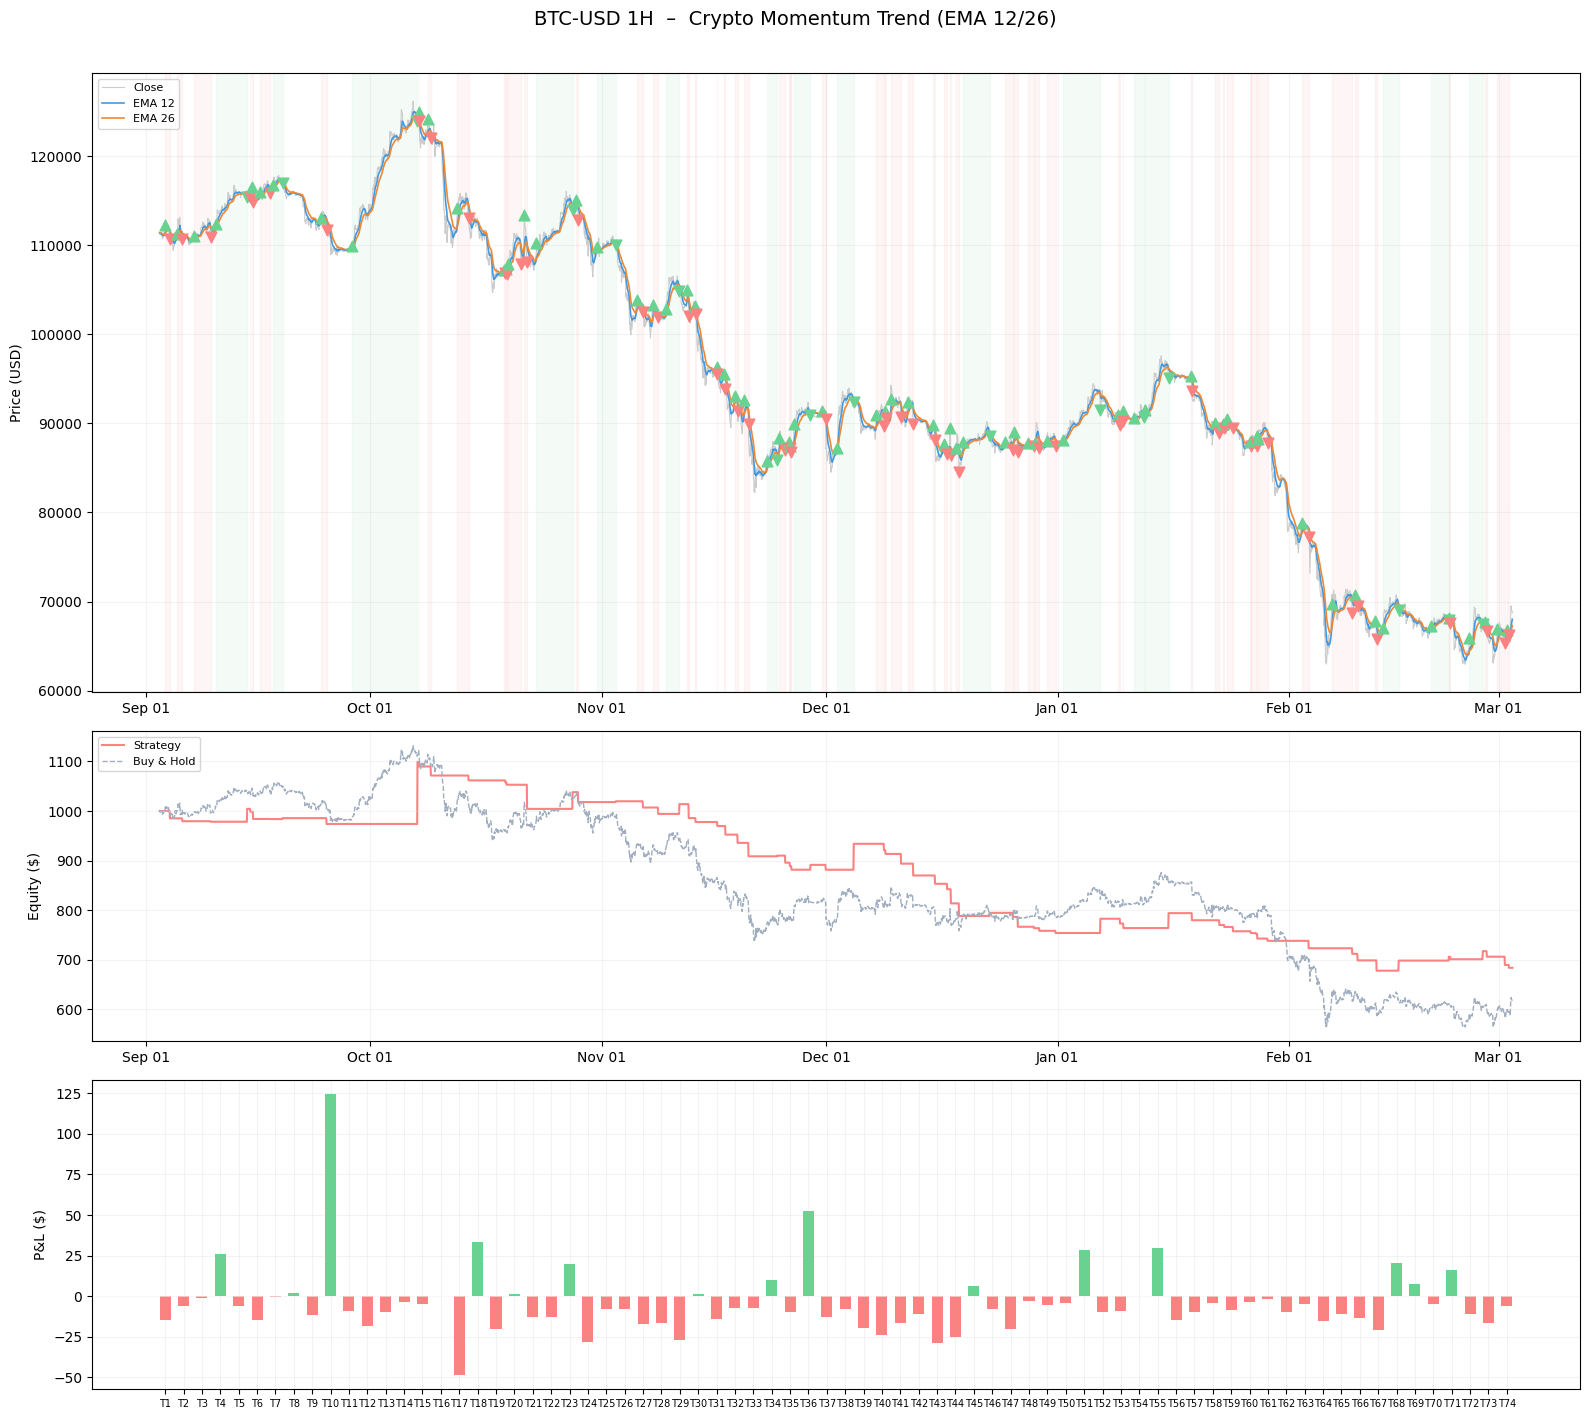

Chart saved → backtest_cmt_results.png


In [6]:
# ── 5. Charts ─────────────────────────────────────────────────────────────────
ec_df = pd.DataFrame(equity_curve).set_index("time")

fig, axes = plt.subplots(3, 1, figsize=(16, 14),
                          gridspec_kw={"height_ratios": [3, 1.5, 1.5]})
fig.suptitle("BTC-USD 1H  –  Crypto Momentum Trend (EMA 12/26)", fontsize=14, y=1.01)

# ── Panel 1: Price + EMAs + entry/exit markers ────────────────────────────────
ax1 = axes[0]
ax1.plot(df.index, df["Close"],    color="#cccccc", lw=0.8, label="Close")
ax1.plot(df.index, df["EMA_fast"], color="#4299e1", lw=1.2, label=f"EMA {FAST}")
ax1.plot(df.index, df["EMA_slow"], color="#ed8936", lw=1.2, label=f"EMA {SLOW}")

if not tdf.empty:
    for _, t in tdf.iterrows():
        color = "#68d391" if t["result"] == "WIN" else "#fc8181"
        ax1.axvspan(t["entry_time"], t["exit_time"], alpha=0.07, color=color)
        ax1.scatter(t["entry_time"], t["entry"], marker="^", color="#68d391", s=60, zorder=5)
        ax1.scatter(t["exit_time"],  t["exit"],  marker="v", color=color,     s=60, zorder=5)

ax1.set_ylabel("Price (USD)")
ax1.legend(loc="upper left", fontsize=8)
ax1.grid(alpha=0.15)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 2: Equity curve vs Buy & Hold ──────────────────────────────────────
ax2 = axes[1]
bh_curve = INITIAL_CAPITAL * (df["Close"] / float(df["Close"].iloc[0]))
color_line = "#68d391" if ec_df["equity"].iloc[-1] >= INITIAL_CAPITAL else "#fc8181"
ax2.plot(ec_df.index,  ec_df["equity"], color=color_line, lw=1.5, label="Strategy")
ax2.plot(df.index,     bh_curve,        color="#a0aec0",  lw=1.0, ls="--", label="Buy & Hold")
ax2.axhline(INITIAL_CAPITAL, color="white", ls=":", lw=0.8, alpha=0.5)
ax2.set_ylabel("Equity ($)")
ax2.legend(loc="upper left", fontsize=8)
ax2.grid(alpha=0.15)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# ── Panel 3: Per-trade P&L bars ───────────────────────────────────────────────
ax3 = axes[2]
if not tdf.empty:
    colors_bar = ["#68d391" if v >= 0 else "#fc8181" for v in tdf["dollar_pnl"]]
    ax3.bar(range(len(tdf)), tdf["dollar_pnl"], color=colors_bar, width=0.6)
    ax3.axhline(0, color="white", lw=0.7, alpha=0.5)
    ax3.set_xticks(range(len(tdf)))
    ax3.set_xticklabels([f"T{i+1}" for i in range(len(tdf))], fontsize=7)
    ax3.set_ylabel("P&L ($)")
ax3.grid(alpha=0.15)

plt.tight_layout()
plt.savefig("backtest_cmt_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved → backtest_cmt_results.png")